In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
DATA_PATH = Path("../data/processed/featured_data.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,Ready To Move,Other,5000.0,9.0,3.0,360.0,11,7200.000000
1,Super built-up Area,Ready To Move,Other,6000.0,12.0,2.0,150.0,11,2500.000000
2,Super built-up Area,Ready To Move,Other,1800.0,1.0,1.0,200.0,1,11111.111111
3,Plot Area,Ready To Move,Other,2360.0,4.0,1.0,650.0,4,27542.372881
4,Super built-up Area,Ready To Move,Other,5425.0,13.0,0.0,275.0,13,5069.124424


In [3]:
X = df.drop(columns=["price"])

y = df["price"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [5]:
MODEL_PATH = Path("../models/best_model.pkl")

model = joblib.load(MODEL_PATH)

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['area_type', 'availability', 'location'], dtype='str'))])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.7, device=None,
                              early_sto...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.01,
                              max_bin=None, max_cat_threshold=None,
                       

In [6]:
predictions = model.predict(X_test)

In [7]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

MAE  : 29.82
MSE  : 3952.10
RMSE : 62.87
R² Score : 0.7742


In [8]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

comparison.head(20)

,Actual Price,Predicted Price
0,73.000,85.360138
1,208.000,307.892639
2,100.000,157.245636
3,59.000,133.074249
4,70.000,99.876450
5,38.000,56.019161
6,650.000,610.801758
7,71.195,70.016205
8,74.030,75.436554
9,52.000,57.700115


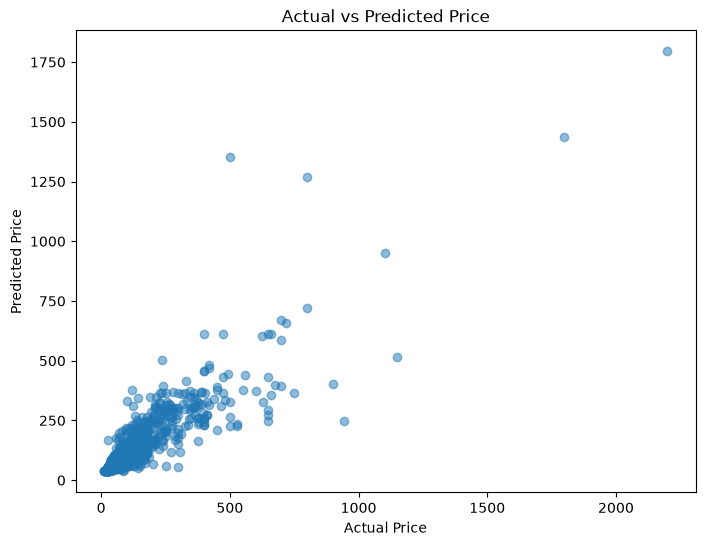

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

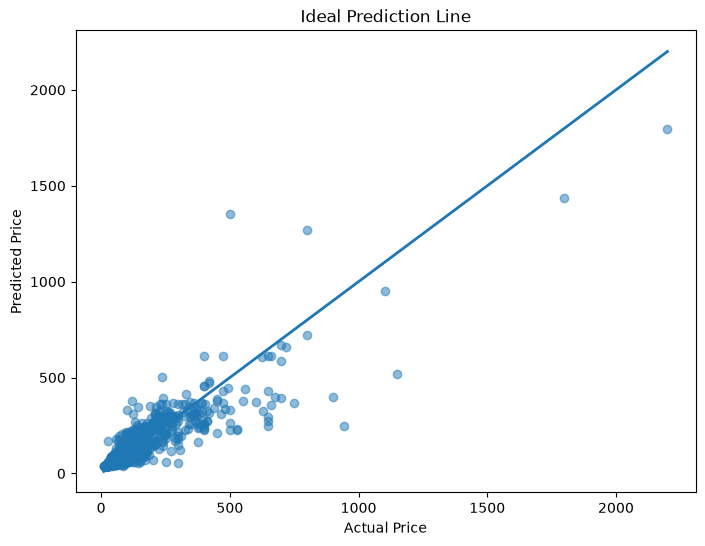

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Ideal Prediction Line")

plt.show()

In [11]:
residuals = y_test - predictions

residuals.head()

3340   -12.360138
7607   -99.892639
3861   -57.245636
6570   -74.074249
3761   -29.876450
Name: price, dtype: float64

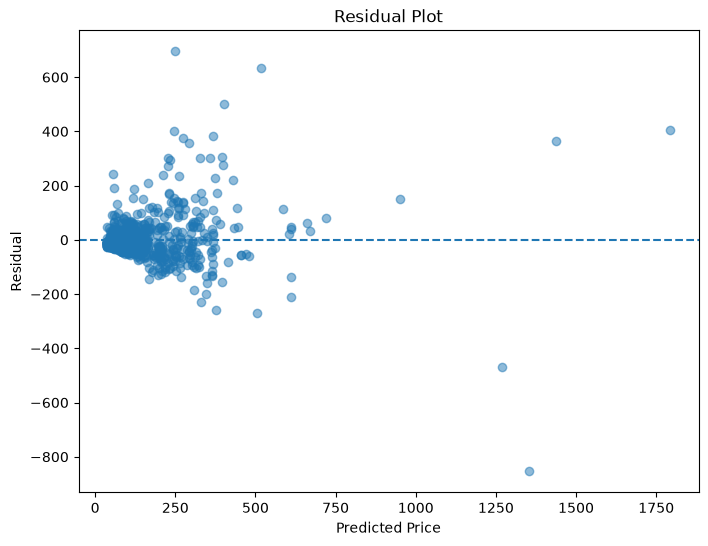

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

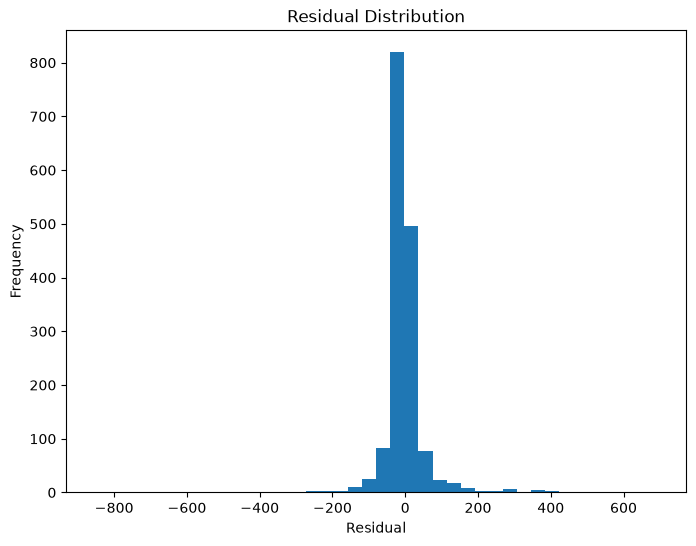

In [13]:
plt.figure(figsize=(8,6))

plt.hist(
    residuals,
    bins=40
)

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.show()

In [14]:
percentage_error = np.abs(
    (y_test - predictions) / y_test
) * 100

percentage_error.head()

3340     16.931696
7607     48.025307
3861     57.245636
6570    125.549575
3761     42.680642
Name: price, dtype: float64

In [15]:
print(
    f"Average Percentage Error : {percentage_error.mean():.2f}%"
)

Average Percentage Error : 29.63%


In [16]:
errors = comparison.copy()

errors["Absolute Error"] = np.abs(
    errors["Actual Price"] -
    errors["Predicted Price"]
)

errors.sort_values(
    by="Absolute Error",
    ascending=False
).head(20)

,Actual Price,Predicted Price,Absolute Error
253,500.0,1354.304688,854.304688
865,943.0,248.374191,694.625809
736,1150.0,516.477295,633.522705
1217,901.0,401.041656,499.958344
1492,800.0,1267.482422,467.482422
770,2200.0,1794.324829,405.675171
214,650.0,247.332535,402.667465
1207,750.0,366.818054,383.181946
1064,649.0,274.453400,374.546600
1366,1800.0,1436.395264,363.604736


In [17]:
trained_model = model.named_steps["model"]

feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": trained_model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

,Feature,Importance
241,remainder__total_sqft,0.165004
30,cat__availability_18-Jan,0.065671
242,remainder__bath,0.061040
117,cat__location_CV Raman Nagar,0.053286
0,cat__area_type_Built-up Area,0.050808
243,remainder__balcony,0.048028
187,cat__location_Kundalahalli,0.041325
42,cat__availability_19-Jan,0.038631
123,cat__location_Cunningham Road,0.036782
31,cat__availability_18-Jul,0.035614


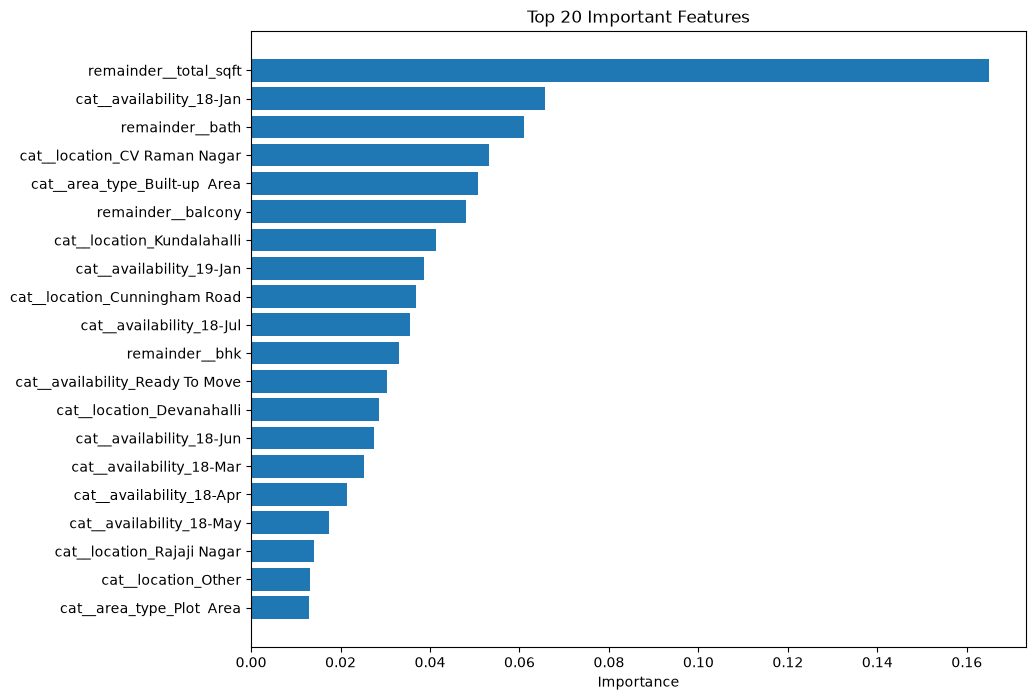

In [18]:
top_features = importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Top 20 Important Features")

plt.show()

In [19]:
metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ],
    "Value": [
        mae,
        mse,
        rmse,
        r2
    ]
})

metrics

,Metric,Value
0,MAE,29.823034
1,MSE,3952.104806
2,RMSE,62.865768
3,R2 Score,0.774202


In [20]:
output_dir = Path("../reports")

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

metrics.to_csv(
    output_dir / "metrics.csv",
    index=False
)

print("Metrics saved successfully!")

Metrics saved successfully!
